# Word Difficulty Estimation & Lexical Ranking

## 1. Project Overview

This sub-project focuses on training a predictive model to estimate the **"知っている"** (Familiarity) index for Japanese vocabulary. This index represents the degree of word recognition among native speakers, serving as a proxy for both word difficulty and popularity within the Japanese lexicon.

By mapping words to a continuous scale (ranging approximately from **-2.0** to **2.3**), the model enables:

* *Dynamic Ranking:* Sorting vocabulary based on perceived familiarity rather than simple frequency counts.
* *Automated Difficulty Classification:* Categorizing words into tiers to match specific user proficiency levels.
* *Personalized Content Generation:* Filtering and selecting optimal targets for language acquisition.

**Note**: This model serves as a core component of the broader Anki Word Generator ecosystem, ensuring that generated flashcards align with the user's current learning trajectory

In [1]:
import re
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from fasttext import load_model
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from scipy.stats import spearmanr
import joblib

## 2. Data Acquisition and Feature Selection

For this project, [I utilized the WLSP-Familiarity Dataset (Version 4.0)](https://github.com/masayu-a/WLSP-familiarity), curated by the *National Institute for Japanese Language and Linguistics* (NINJAL). This comprehensive dataset contains linguistic metrics for over 100,000 Japanese words.

While the dataset provides diverse metadata, this model focuses exclusively on the word and the **"知っている"** (Familiarity) index.

**Rationale:** Since the final *Anki Word Generator* will primarily process raw text input (words) without access to specialized linguistic metadata, the model must be trained to predict difficulty based solely on the lexical properties of the word itself

In [2]:
df = pd.read_csv('bunruidb-fam.csv', encoding='utf-8-sig')
pd.set_option('display.max_columns', None)

print(df.shape)
df.head()

(101067, 26)


,レコードＩＤ番号,見出し番号,レコード種別,類,部門,中項目,分類項目,分類番号,段落番号,小段落番号,語番号,見出し,見出し本体,読み,逆読み,知っている,書く,読む,話す,聞く,生産,受容,書記,音声,生産-受容,書記-音声
0,1,1,A,体,関係,事柄,事柄,1.1,1,1,1,者（もの）,者,もの,のも,1.466420,0.569324,0.621675,0.559391,0.733162,1.128715,1.354837,1.190999,1.292553,-0.226122,-0.101554
1,2,2,A,体,関係,事柄,事柄,1.1,1,1,2,の,の,の,の,0.681905,0.900859,0.998970,0.944396,0.956736,1.845255,1.955706,1.899829,1.901132,-0.110451,-0.001303
2,3,3,A,体,関係,事柄,事柄,1.1,1,1,3,分（ぶん）,分,ぶん,んぶ,1.041595,0.548134,0.562989,0.399093,0.543941,0.947227,1.106930,1.111123,0.943035,-0.159703,0.168089
3,4,4,A,体,関係,事柄,事柄,1.1,1,1,4,やつ,やつ,やつ,つや,1.243173,0.416562,0.578044,0.557592,0.661892,0.974154,1.239936,0.994606,1.219484,-0.265782,-0.224878
4,5,5,A,体,関係,事柄,事柄,1.1,1,2,1,−こ［椀〜］,−こ,こ,こ,-0.397368,-1.149494,-1.134444,-1.147348,-1.133315,-2.296842,-2.267758,-2.283938,-2.280663,-0.029084,-0.003275


In this stage, I refine the dataset by isolating the core *word* and *familiarity* columns. I implement a specific filter to exclude entries starting with **'−'**, as these represent suffixes and bound morphemes rather than standalone vocabulary.

**Objective:** Since the downstream *Anki Word Generator* is designed to process individual lexical units, removing these suffixes ensures the model's training data remains consistent with its real-world application, focusing exclusively on valid, independent Japanese words

In [3]:
df = df[['見出し本体','知っている']]

df['見出し本体'] = df['見出し本体'].apply(lambda x: np.nan if x.startswith('−') else x)
df = df.dropna()
df

,見出し本体,知っている
0,者,1.466420
1,の,0.681905
2,分,1.041595
3,やつ,1.243173
5,対象,1.853723
...,...,...
101062,すいっちょ,-0.963837
101063,みんみん,0.609637
101064,じーじー,0.452110
101065,かなかな,-0.707855


To enhance the model's predictive power, I derive three new numerical features from the raw text. These features capture the visual and structural complexity of Japanese words:

* *Word Length* (`単語の長さ`): The total character count.

* *Hiragana Count* (`ひらがな数`): Extracted using Regex to identify phonetically simple components.

* *Kanji Count* (`漢字数`): Extracted using Unicode range filtering to represent lexical density and academic depth.

**Note:** Katakana count was intentionally omitted to prevent multi-collinearity, ensuring the independence of our input features

In [4]:
df['単語の長さ'] = df['見出し本体'].apply(lambda x: len(x))
df['ひらがな数'] = df['見出し本体'].apply(lambda x: sum([len(sym) for sym in re.findall(r'[\u3040-\u309F]+', x)]))
df['漢字数'] = df['見出し本体'].apply(lambda x: sum([len(sym) for sym in re.findall(r'[\u4E00-\u9FFF]+', x)]))
df

,見出し本体,知っている,単語の長さ,ひらがな数,漢字数
0,者,1.466420,1,0,1
1,の,0.681905,1,1,0
2,分,1.041595,1,0,1
3,やつ,1.243173,2,2,0
5,対象,1.853723,2,0,2
...,...,...,...,...,...
101062,すいっちょ,-0.963837,5,5,0
101063,みんみん,0.609637,4,4,0
101064,じーじー,0.452110,4,2,0
101065,かなかな,-0.707855,4,4,0


## 3. Exploratory Data Analysis (EDA)

Generating descriptive statistics for the Data Frame. This provides a high-level overview of the distribution's range, mean, and standard deviation, helping to identify potential outliers or skewness in the data

In [5]:
df.describe()

,知っている,単語の長さ,ひらがな数,漢字数
count,100373.000000,100373.000000,100373.000000,100373.000000
mean,0.984609,3.336027,1.182858,1.742471
std,0.898286,1.573694,1.607199,1.031940
min,-1.782747,1.000000,0.000000,0.000000
25%,0.385060,2.000000,0.000000,1.000000
50%,1.339801,3.000000,0.000000,2.000000
75%,1.692027,4.000000,2.000000,2.000000
max,2.356011,26.000000,17.000000,12.000000


The summary statistics confirm the scale of our target variable, with a mean familiarity score of approximately **0.98** and a maximum of **2.35**. The standard deviation of **0.89** suggests sufficient variance for the model to learn distinct difficulty tiers. The feature ranges (e.g., Kanji count from 0 to 12) provide a solid numerical foundation for training the linear regressor

To gain deeper insights into the dataset, I visualized the distributions of the target variable and the engineered features

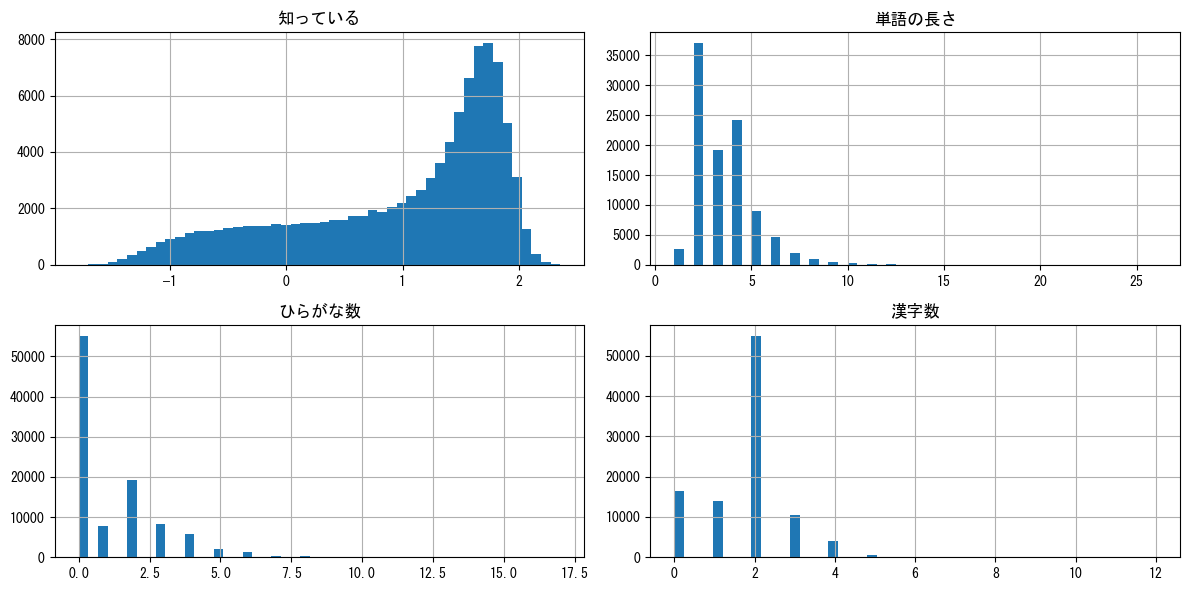

In [6]:
plt.rcParams['font.family'] = 'MS Gothic' 

fig, axes = plt.subplots(figsize=(12, 6), ncols=2, nrows=2)

df['知っている'].hist(bins=50, ax=axes[0][0])
axes[0][0].set_title('知っている')

df['単語の長さ'].hist(bins=50, ax=axes[0][1])
axes[0][1].set_title('単語の長さ')

df['ひらがな数'].hist(bins=50, ax=axes[1][0])
axes[1][0].set_title('ひらがな数')

df['漢字数'].hist(bins=50, ax=axes[1][1])
axes[1][1].set_title('漢字数')
plt.tight_layout()
plt.show()

Initial analysis revealed a significant negative skew in the **'知っている'** (Familiarity) index, which could lead to poor model performance on less common words. To address this, I applied a logarithmic transformation to the target variable. The Transformation: I utilized the formula $\ln(max\_val + 1 - x)$ to normalize the distribution.

**Rationale:** This approach converts the skewed distribution into a *near-normal* bell curve. In neural network training, normally distributed targets help stabilize the loss function and prevent the model from becoming biased towards high-frequency samples. This ensures more granular and accurate predictions across the entire difficulty spectrum—from basic everyday vocabulary to advanced academic terms

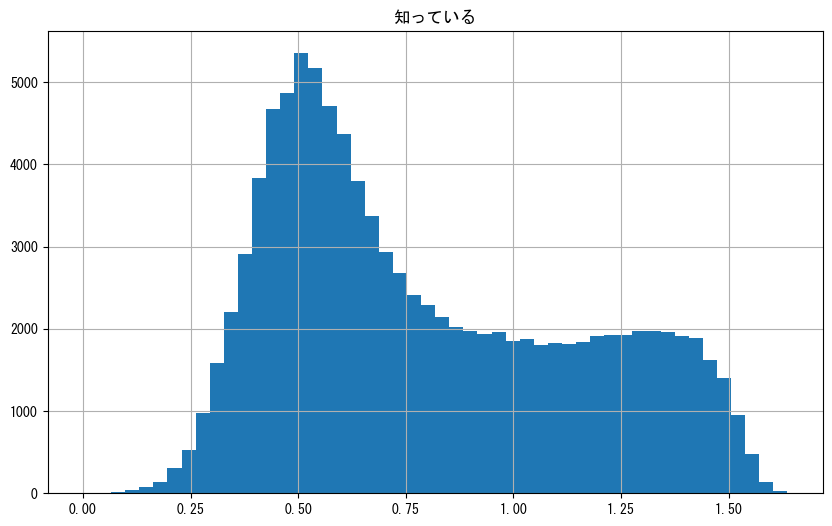

In [7]:
max_familiarity = df['知っている'].max()
df['知っている'] = df['知っている'].apply(lambda x: np.log(max_familiarity + 1 - x))

fig, ax = plt.subplots(figsize=(10, 6))
df['知っている'].hist(bins=50, ax=ax)
ax.set_title('知っている')
plt.show()

*Feature Distributions*: Metrics like Word Length and Kanji Count follow a Poisson-like distribution, where most words are short (2–5 characters) and contain 1–2 Kanji.

The histogram indicate that wird lengths exceeding 10 characters are *very rare*. Let's examine these outliers in more detail

In [8]:
df[df['単語の長さ'] >= 10]

,見出し本体,知っている,単語の長さ,ひらがな数,漢字数
260,バーチャルリアリティー,0.726725,11,0,0
6438,付ききり・付きっきり,0.760671,10,7,2
6493,別れ別れ・分かれ分かれ,0.538894,11,6,4
6708,目の上のこぶ／のたんこぶ,0.474631,12,9,2
7249,引き伸ばし・引き延ばし,0.404101,11,6,4
...,...,...,...,...,...
100850,よろしゅうございます,0.594212,10,10,0
100916,さようなら・さよなら,0.417916,10,9,0
100930,御機嫌よう／よろしゅう,0.520615,11,7,3
100935,お後がよろしいようで,0.482080,10,9,1


An inspection of the outliers reveals that most entries are not unique tokens, but rather multiple variants or readings of the same word separated by delimiters. To maintain data consistency, I will **preprocess** these rows by retaining only only the first occurrence

In [9]:
df['見出し本体'] = df['見出し本体'].apply(lambda x: x.split('・')[0].split('／')[0])

df['単語の長さ'] = df['見出し本体'].apply(lambda x: len(x))
df['ひらがな数'] = df['見出し本体'].apply(lambda x: sum([len(sym) for sym in re.findall(r'[\u3040-\u309F]+', x)]))
df['漢字数'] = df['見出し本体'].apply(lambda x: sum([len(sym) for sym in re.findall(r'[\u4E00-\u9FFF]+', x)]))

Let's examine the distribution following the data preprocessing stage

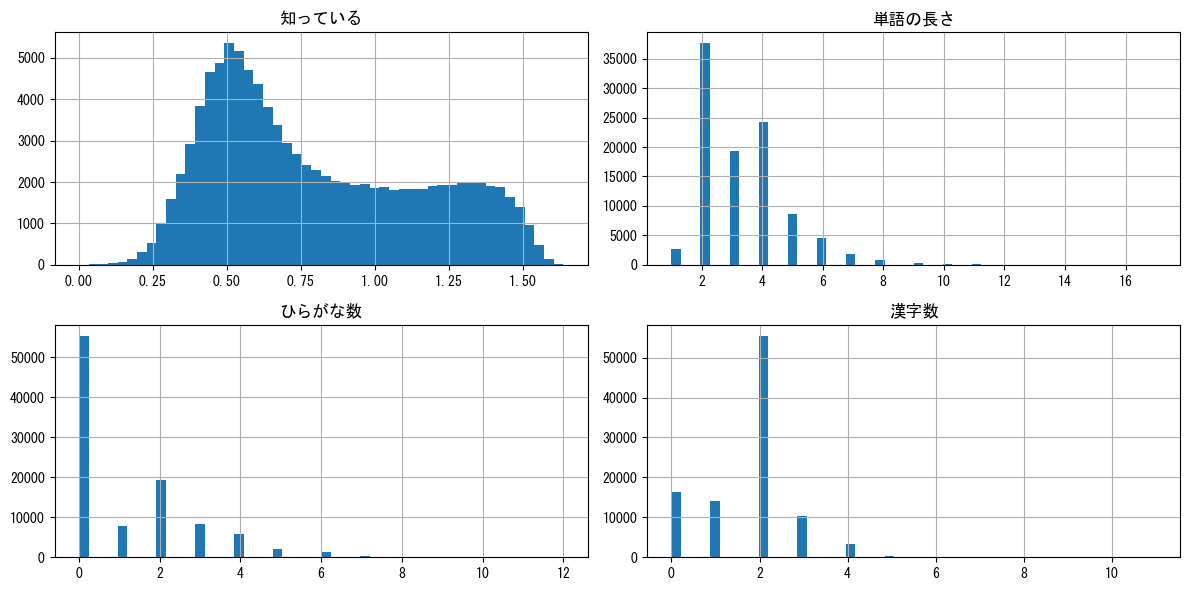

In [10]:
fig, axes = plt.subplots(figsize=(12, 6), ncols=2, nrows=2)

df['知っている'].hist(bins=50, ax=axes[0][0])
axes[0][0].set_title('知っている')

df['単語の長さ'].hist(bins=50, ax=axes[0][1])
axes[0][1].set_title('単語の長さ')

df['ひらがな数'].hist(bins=50, ax=axes[1][0])
axes[1][0].set_title('ひらがな数')

df['漢字数'].hist(bins=50, ax=axes[1][1])
axes[1][1].set_title('漢字数')
plt.tight_layout()
plt.show()

The updated distribution appears much more realistic. Notably, the abscence of zero-length entries congirms that the data cleaning was successful. While some outliers remain, we will now proceed to investigate them

In [11]:
df[df['単語の長さ'] >= 10]

,見出し本体,知っている,単語の長さ,ひらがな数,漢字数
260,バーチャルリアリティー,0.726725,11,0,0
8095,はしが転んでもおかしい年ごろ,0.872598,14,12,2
9672,オールドファッション,0.760505,10,0,0
10845,フェースツーフェース,0.972564,10,0,0
13819,コストパフォーマンス,0.315225,10,0,0
...,...,...,...,...,...
100664,あろう事かあるまい事か,0.807730,11,9,2
100751,アテンションプリーズ,0.504561,10,0,0
100810,さようでございますか,0.593145,10,10,0
100850,よろしゅうございます,0.594212,10,10,0


The remaining outliers consist of longer Katakana terms and complex idiomatic expressions, such as **'あろう事かあるまい事か'**. Since these are legitimate linguistic structures rather than data errors, retaining them will allow the model to capture more sophisticated semantic patterns

## 4 Data Splitting and Model Creating

Following data cleaning and feature engineering, I partitioned the dataset into features (**X**) and the target variable (**y**) and the quantitative metrics including word length, Hiragana count, and Kanji density (**X_info**).

By concatenating these features, the model can leverage both the abstract meaning and the visual/orthographic complexity of the Japanese text to predict its familiarity index

In [12]:
X = df['見出し本体']
y = df['知っている']
X_info = df[['単語の長さ', 'ひらがな数', '漢字数']]

To transform raw text into a format suitable for machine learning, I utilized a pre-trained FastText model (**cc.ja.300.bin**).

**Rationale**: Unlike standard *Word2Vec*, *FastText* accounts for sub-word information (n-grams), which is particularly effective for the complex morphology of the Japanese language. Since our task lacks surrounding sentence context, these static embeddings provide a dense, 300-dimensional semantic representation of each word based on its usage in large-scale Japanese web corpora

In [13]:
model = load_model("C:\\Users\\AORUS 16X\\PycharmProjects\\Anki_card_generator\\model\\cc.ja.300.bin")

X_vec = np.array([model.get_word_vector(word) for word in X])

I performed a *stratified-style split* (**75/25**) to create training and validation sets. To ensure full traceability and facilitate error analysis, I synchronized the split across four components:

* **X_train / X_test**: Word embeddings used for learning.
* **y_train / y_test**: The target **'知っている'** (Familiarity) scores.
* **X_info_train / X_info_test**: The quantitative metrics including word length, Hiragana count, and Kanji density for learning.
* **X_word_test**: The raw Japanese strings, allowing for a qualitative review of *'outlier'* predictions where the model significantly deviates from the ground truth

In [14]:
X_train, X_test, y_train, y_test, X_info_train, X_info_test, X_word_train, X_word_test = train_test_split(X_vec, y, X_info, X, test_size=0.25, random_state=42)

To ensure stable convergence during training, I applied **Min-Max Scaling** to both the semantic embeddings and the structural features.

**Why separate scalers?** I used distinct scaling instances for the 300-dimensional vectors and the 3-dimensional metadata (`X_info`). This prevents the magnitude of raw counts (like word length) from disproportionately influencing the loss function, ensuring all features contribute equally to the gradient updates

In [15]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

info_scaler = MinMaxScaler()
X_info_train_scaled = info_scaler.fit_transform(X_info_train)
X_info_test_scaled = info_scaler.transform(X_info_test)

In this step, I converted the processed NumPy arrays into *PyTorch Tensors* and encapsulated them within a `TensorDataset`. 

**Architecture Strategy:** The dataset is structured to support a *multi-input model architecture*. Each sample consists of:
1. **Semantic Tensor:** The 300D FastText embedding.
2. **Structural Tensor:** The 3D normalized metadata (Length, Hiragana, Kanji counts).
3. **Target Tensor:** The continuous **'知っている'** (Familiarity) index.

I then initialized *DataLoaders* with a batch size of 128. Shuffling is enabled for the training set to prevent the model from learning the order of the data, while the test loader remains sequential for consistent evaluation

In [16]:
train_dataser = TensorDataset(torch.tensor(X_train_scaled, dtype=torch.float32),
                              torch.tensor(X_info_train_scaled, dtype=torch.float32),
                              torch.tensor(y_train.to_numpy(), dtype=torch.float32).view(-1, 1))

test_dataser = TensorDataset(torch.tensor(X_test_scaled, dtype=torch.float32),
                             torch.tensor(X_info_test_scaled, dtype=torch.float32),
                             torch.tensor(y_test.to_numpy(), dtype=torch.float32).view(-1, 1))

train_loader = DataLoader(train_dataser, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataser, batch_size=128, shuffle=False)

I designed a *Multi-Layer Perceptron (MLP)* regressor optimized for high-dimensional feature fusion. The architecture is specifically tailored to process both semantic and structural information simultaneously.

**Key Architectural Components:**

* **Input Fusion Layer**: The model accepts a *303-dimensional input*, created by concatenating the 300D FastText word vector with the 3D structural metadata (Length, Hiragana, Kanji).
* **Hidden Layers**:
    * *Fully Connected Layer 1 (128 units)*: Captures complex interactions between the word's meaning and its visual complexity.
    * *Dropout (0.2)*: Implemented for regularization, preventing the model from over-relying on specific training samples and improving its ability to generalize to new Japanese vocabulary.

    * *Fully Connected Layer 2 (32 units)*: Further compresses the learned representations into a compact feature space.

* **Activation Function**: *ReLU* is used throughout the hidden layers to introduce non-linearity, allowing the model to learn that 'difficulty' doesn't always scale linearly with word length.

* **Output Layer**: A single linear neuron that predicts the continuous **'知っている'** (Familiarity) index

In [17]:
class WordFrequencyRegressor(nn.Module):
    def __init__(self, embedding_dim=300, extra_features_dim=3):
        super().__init__()

        input_dim = embedding_dim + extra_features_dim

        self.fc1 = nn.Linear(input_dim, 128)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(128, 32)
        self.fc3 = nn.Linear(32, 1)

    def forward(self, word_vector, extra_features):
        combined = torch.cat((word_vector, extra_features), dim=1)

        x = self.fc1(combined)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.relu(x)

        out = self.fc3(x)
        return out

## 5 Model Training and Performance Evaluation

The model was trained using the Adam optimizer and **Mean Squared Error (MSE)** as the loss function. While MSE is effective for minimizing the distance between predicted and actual familiarity scores, I introduced a secondary metric to evaluate the model's practical utility for the Anki generator.

**Key Metrics:**
* *Mean Squared Error (MSE)*: Used as the primary objective function. It penalizes larger deviations more heavily, ensuring the model stays accurate across the entire scale of the Japanese lexicon.

* *Spearman’s Rank Correlation*: Since the ultimate goal is to rank words, Spearman’s correlation is the most critical metric. Unlike linear correlation, Spearman assesses how well the relationship between the ranks is preserved.

    * *Significance:* A high Spearman score indicates that if the model predicts Word A is harder than Word B, it is highly likely to be true in the real-world dataset, regardless of the absolute numerical values.

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model = WordFrequencyRegressor().to(device)

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

epochs = 40
best_test_loss = float('inf')
train_losses = []
test_losses = []
spearman_corr = []


for epoch in range(epochs):

    model.train()
    train_loss = 0
    k = len(train_loader)

    for batch_X, batch_X_info, batch_y in train_loader:
        batch_X, batch_X_info, batch_y = batch_X.to(device), batch_X_info.to(device), batch_y.to(device)

        predictions = model(batch_X, batch_X_info)
        loss = loss_fn(predictions, batch_y)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        train_loss += loss.item()

    train_loss /= k

    train_losses.append(train_loss)

    model.eval()

    preds = []
    targets = []

    with torch.no_grad():

        test_loss = 0
        k = len(test_loader)

        for batch_X, batch_X_info, batch_y in test_loader:
            batch_X, batch_X_info, batch_y = batch_X.to(device), batch_X_info.to(device), batch_y.to(device)

            predictions = model(batch_X, batch_X_info)
            loss = loss_fn(predictions, batch_y)

            preds.append(predictions.cpu().numpy())
            targets.append(batch_y.cpu().numpy())
            test_loss += loss.item()

    y_pred = np.concatenate(preds).flatten()
    y_true = np.concatenate(targets).flatten()

    rho, _ = spearmanr(y_true, y_pred)
    test_loss /= k
    test_losses.append(test_loss)

    spearman_corr.append(rho)

    if test_loss < best_test_loss:
        best_test_loss = test_loss
        torch.save(model.state_dict(), "best_model.pth")
    print(f'Epoch {epoch} is ended')

cuda
Epoch 0 is ended
Epoch 1 is ended
Epoch 2 is ended
Epoch 3 is ended
Epoch 4 is ended
Epoch 5 is ended
Epoch 6 is ended
Epoch 7 is ended
Epoch 8 is ended
Epoch 9 is ended
Epoch 10 is ended
Epoch 11 is ended
Epoch 12 is ended
Epoch 13 is ended
Epoch 14 is ended
Epoch 15 is ended
Epoch 16 is ended
Epoch 17 is ended
Epoch 18 is ended
Epoch 19 is ended
Epoch 20 is ended
Epoch 21 is ended
Epoch 22 is ended
Epoch 23 is ended
Epoch 24 is ended
Epoch 25 is ended
Epoch 26 is ended
Epoch 27 is ended
Epoch 28 is ended
Epoch 29 is ended
Epoch 30 is ended
Epoch 31 is ended
Epoch 32 is ended
Epoch 33 is ended
Epoch 34 is ended
Epoch 35 is ended
Epoch 36 is ended
Epoch 37 is ended
Epoch 38 is ended
Epoch 39 is ended


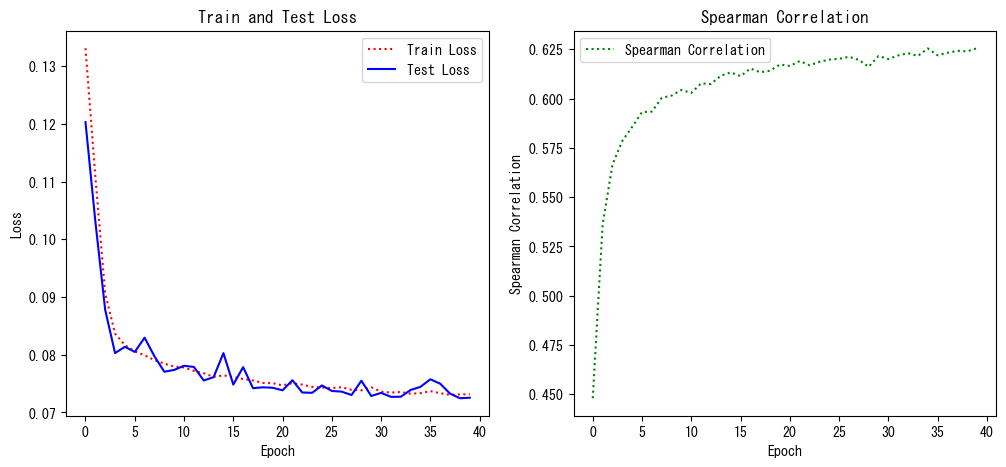

In [19]:
fig, axes = plt.subplots(figsize=(12, 5), nrows=1, ncols=2)

axes[0].plot(train_losses, label='Train Loss', ls=':', color='red')
axes[0].plot(test_losses, label='Test Loss', ls='-', color='blue')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].set_title('Train and Test Loss')

axes[1].plot(spearman_corr, label='Spearman Correlation', ls=':', color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Spearman Correlation')
axes[1].legend()
axes[1].set_title('Spearman Correlation')

plt.show()

The training history demonstrates a healthy and stable learning process:

* *Loss Convergence:* Both Training and Test Loss reached a stable plateau after approximately 25 epochs, indicating that the model successfully converged without signs of overfitting.

* *Spearman Rank Correlation (0.625)*: The model achieved a Spearman correlation of 0.625 on the held-out test set. Considering the inherent complexity and subjectivity of linguistic familiarity, this represents a strong predictive capability.

**Conclusion:** The proximity of the training and validation curves confirms the model's ability to generalize effectively to new, unseen Japanese words. This performance level is more than sufficient for high-quality word ranking and automated difficulty selection within the *Anki Word Generator system*

In [20]:
joblib.dump(scaler, 'scaler.gz')
joblib.dump(info_scaler, 'info_scalar.gz')

['info_scalar.gz']

## 6 Error Analysis

I performed an audit of the top 20 words where the model showed the *highest Absolute Error*. This process, known as Residual Analysis, helps identify systematic biases in the model's logic.

**Key Observations:**

* **False Positives for Simple Structures:** The model tends to underestimate the difficulty of rare words that have a 'simple' visual appearance (e.g., short words or those written in basic Hiragana/Kanji).

* **Semantic Noise:** Proper nouns (names of historical figures or specific Buddhist sects like 三論宗) are occasionally misclassified as 'familiar' because their FastText embeddings might place them near more common concepts.

In [23]:
model.eval()

preds = []
true = []

with torch.no_grad():
    for i in range(len(X_test)):
        vec = torch.tensor(X_test_scaled[i], dtype=torch.float32).unsqueeze(0).to(device)
        info = torch.tensor(X_info_test_scaled[i], dtype=torch.float32).unsqueeze(0).to(device)
        
        pred = model(vec, info).item()
        preds.append(pred)
        true.append(y_test.values[i])

analysis_df = pd.DataFrame({'word': X_word_test, 'prediction value': preds, 'true value': true})

analysis_df['prediction value'] = analysis_df['prediction value'].apply(lambda x: max_familiarity + 1 - np.exp(x))
analysis_df['true value'] = analysis_df['true value'].apply(lambda x: max_familiarity + 1 - np.exp(x))

analysis_df['abs error'] = (analysis_df['true value'] - analysis_df['prediction value']).abs()

analysis_df.sort_values(by='abs error', ascending=False).head(20)

,word,prediction value,true value,abs error
73560,くる,1.654435,-1.209520,2.863955
22206,無何有のさと,1.291506,-1.546502,2.838009
63655,かまつか,1.101183,-1.671124,2.772307
26636,三論宗,1.151263,-1.618299,2.769562
82747,盤踞する,1.040805,-1.724322,2.765127
34887,異類婚姻譚,1.230500,-1.512385,2.742885
26632,倶舎宗,1.241753,-1.485946,2.727698
13489,列氏温度,1.392236,-1.335132,2.727369
97141,高名嘖嘖,1.074700,-1.624167,2.698868
18751,ケマル‐アタチュルク,1.322369,-1.373830,2.696199


To validate the model's reliability, I extracted the top 20 words with the *lowest Absolute Error*. The results are highly encouraging, showing near-perfect alignment with the ground truth.

**Key Observations:**

* *High Accuracy on Intermediate Lexicon:* The model excels at predicting the familiarity of words typically found in the JLPT N3–N2 range (e.g., *無表情 - expressionless*, *不可避 - unavoidable*).

* *Balanced Feature Integration:* For these words, the combination of FastText embeddings (semantic context) and structural features (Kanji/Length) works in perfect harmony.

**Reliability:** The extremely low error rate (near zero) for these diverse lexical items proves that the regressor is ready for deployment in the *Anki Word Generator*, where consistent difficulty estimation is crucial for a smooth user experience

In [24]:
analysis_df.sort_values(by='abs error', ascending=True).head(20)

,word,prediction value,true value,abs error
40369,倉庫荒し,1.160125,1.160176,0.000051
9546,中ごろ,1.381633,1.381450,0.000183
97727,まっすぐ,1.617945,1.617750,0.000195
95796,無表情,1.760440,1.760651,0.000212
36781,衣食住,1.585773,1.585556,0.000218
280,不正,1.773167,1.773394,0.000227
67478,有する,1.148827,1.148493,0.000334
5554,入洛,-0.073923,-0.073587,0.000336
22194,霊界,1.350195,1.350538,0.000343
32092,系譜,0.921467,0.921123,0.000343


# Final Conclusion

This project provided valuable insights into the intersection of Natural Language Processing and Japanese linguistics. Building a model to quantify lexical familiarity was both a technical and personal challenge.

**Key Takeaways:**

* Working with the Japanese language requires a nuanced approach to feature engineering, balancing semantic embeddings with orthographic data (Kanji/Kana counts).

* While there is always room for optimization—such as integrating frequency-based sub-models or more complex architectures—the current model’s performance (Spearman 0.625) is more than sufficient for its intended purpose.

**Future Outlook:** This model successfully serves as the 'intelligence' behind my Anki Word Generator, enabling automated difficulty sorting and personalized vocabulary selection. I look forward to further exploring *Japanese NLP* and refining these tools for more efficient language acquisition